<a href="https://colab.research.google.com/github/ErnestoPalchetti-sp/LSTM-for-Timeseries/blob/main/Project_Description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from Classes_and_Functions import NetLSTM
import torch as th
from torch import nn
import numpy as np
import pandas as pd
from torch import optim
from torch.nn import functional as F
from torch.autograd import Variable
import torch.utils.data as th_data
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import json
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# LSTM for running metrics timeseries
## Project Description
The current project is an example of use of a LSTM network for timeseries forecasting. LSTM is a __recurrent neural network__ that allows us to handle the long time dependecies avoiding the exploding gradient, a common issue of neural network for timeseries.
The dataset consists in a selection of running metrics extrapolated from a __.fit__ file of a marathon, runned by myself. The metrics are recorded with a Garmin Forerunner 965 combined with the HRM pro band, and are exported from the [Garmin Connect](https://connect.garmin.com/) website.
The main refrences are [AI summer](https://theaisummer.com/gru/), [Machine Learning Mastery](https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/), and [Deep Learning](https://www.deeplearningbook.org/) by Yoshua Bengio and Aaron Courville.

## Data Preview
The dataset is imported with the use of the __fitparse__ package that allow us to ope a __.fit__ file. The file contains many running metrics, and some of them are explicitly named in the file. In the set of possible quantities, I used the followings:
- __Strdie length__ (_mm_)
- __Stance time__ (_ms_)
- __Time__ (_min_)
- __distance__ (_m_)
- __hearth rate__ (_bpm_)
- __speed__ (_min/km_)
- __gained elevbation__ (_m_)
- __vertical oscillation__ (_mm_)

The last one, the vertical oscillation paramter, is the target variable of the model.


In [9]:
# @title
if th.cuda.is_available():
  device='cuda'
else:
  device='cpu'
df=pd.read_csv("final_dataset.csv")
df.reset_index()
X=th.Tensor(df.iloc[:len(df.Time)-1,0:].values)
y=th.Tensor(df.iloc[1:,7].values)
x_min=X.min(dim=0, keepdim=True).values
x_max=X.max(dim=0, keepdim=True).values
X=(X - x_min) / (x_max - x_min)
y_min=y.min(dim=0, keepdim=True).values
y_max=y.max(dim=0, keepdim=True).values
y=(y - y_min) / (y_max - y_min)
X=X.to(device)
X.device
X=X.unsqueeze(1)
#print(X.shape)
y=y.to(device)

y=y.unsqueeze(1)
y=y.unsqueeze(2)

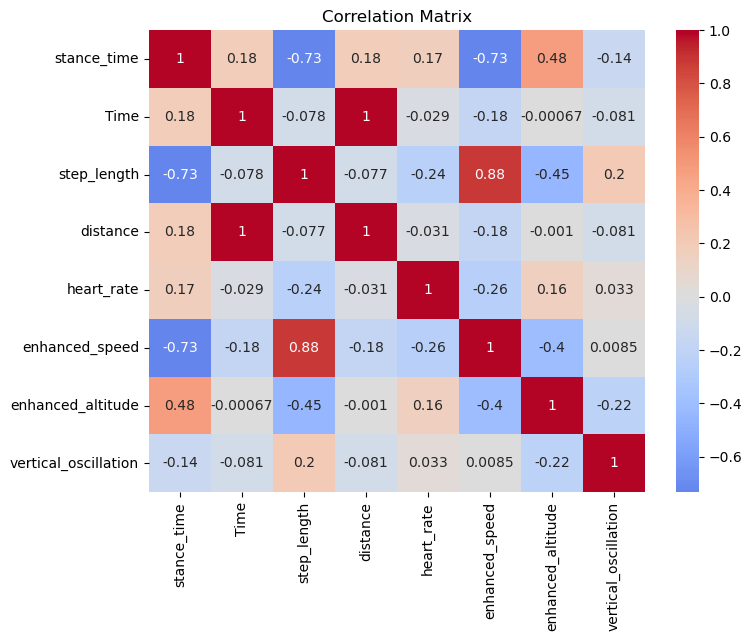

In [10]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

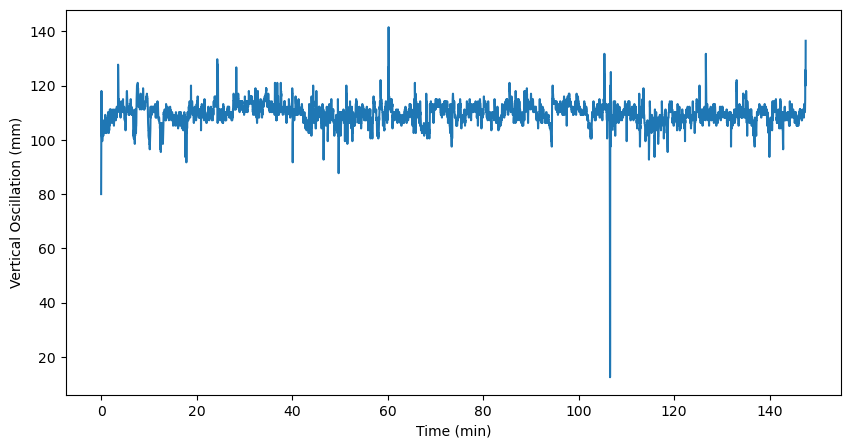

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df.Time,df.vertical_oscillation)
plt.xlabel("Time (min)")
plt.ylabel("Vertical Oscillation (mm)")
plt.show()

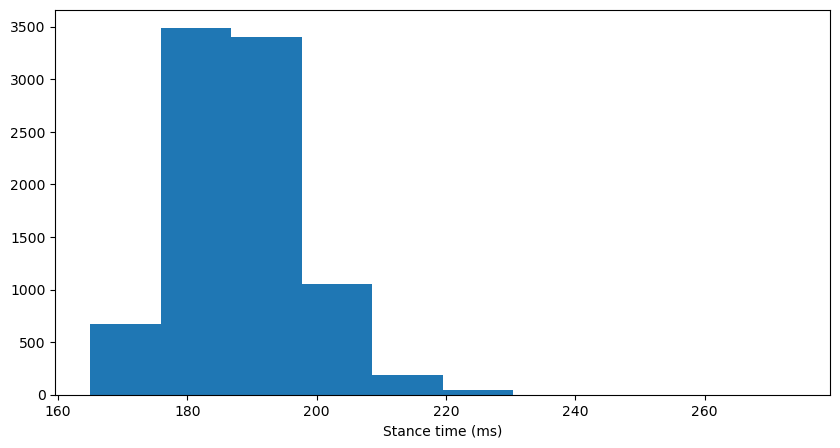

In [12]:
plt.figure(figsize=(10,5))
plt.hist(df.stance_time)
plt.xlabel("Stance time (ms)")
plt.show()

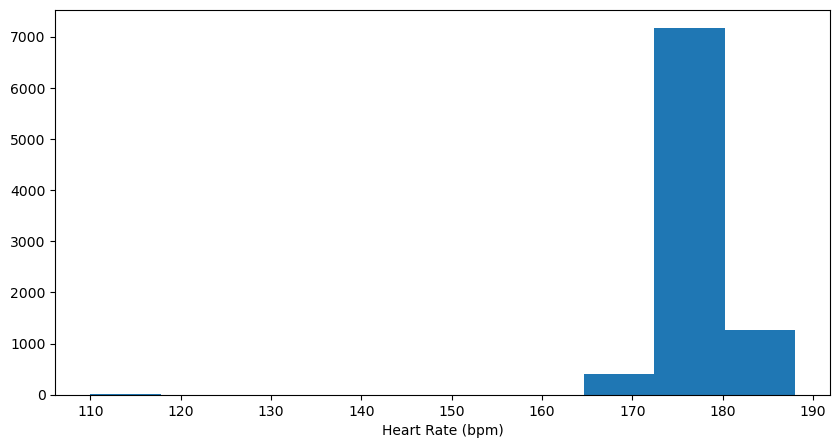

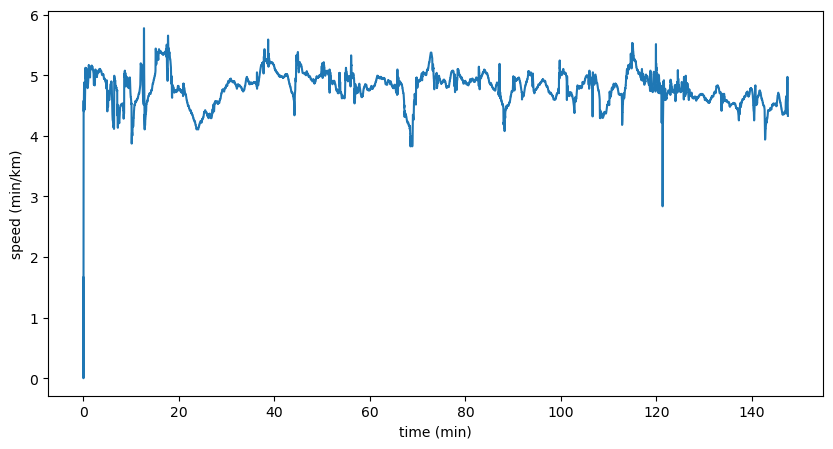

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df.heart_rate)
plt.xlabel("Heart Rate (bpm)")
plt.show()
plt.figure(figsize=(10,5))
plt.plot(df.Time,df.enhanced_speed)
plt.xlabel("time (min)")
plt.ylabel("speed (min/km)")
plt.show()

## The model
I chose an LSTM network, implemented with __pytorch__ to handle the long time dependencies of the timeseries, even if the dimension of the problem allows a less complex solution, such as an RNN.  
The following code is the core definition of the model and the _train_ method.

In [14]:
class NetLSTM(nn.Module):
    def __init__(self,indim,hDim):
        super().__init__()
        self.strati=len(hDim)
        self.n_layers=len(hDim)
        define=[indim]+list(hDim)
        layer_list=list()
        for i in range(self.n_layers):
            layer_list.append(nn.LSTM(define[i],define[i+1],1))
        self.dense=nn.Linear(define[-1],1)
        self.layers=nn.ModuleList(layer_list)

    def forward(self,x,c_ts=[],h_ts=[]):
        if not c_ts:
            c_ts=[]
            h_ts=[]
            for i in range(self.n_layers):
                c_ts.append(th.zeros(1,self.layers[i].hidden_size,device=x.device.type))
                h_ts.append(th.zeros(1,self.layers[i].hidden_size,device=x.device.type))
        out=list()
        for xi in x:
            for j,f in enumerate(self.layers):
                xi,(h_t,c_t)=f(xi,(h_ts[j],c_ts[j]))
                c_ts[j]=c_t
                h_ts[j]=h_t
            xi=self.dense(xi)
            out.append(xi)
        out=th.stack(out,dim=0)

        return out.reshape(out.shape,1,1),c_ts,h_ts


    def test(self,x,y,plot=0):
        outputs, h_t,c_t=self(x)
        y=y.reshape(outputs.shape).float()
        error=F.mse_loss(outputs,y).item()

        return error


    def train(self,x_train,y_train,batch_size,plot=0,epochs=100,lr=0.001):

        criterion=nn.MSELoss()
        optimizer=optim.Adam(self.parameters(),lr=lr)
        losses=list()
        loader = th_data.DataLoader(th_data.TensorDataset(x_train, y_train), shuffle=False, batch_size=batch_size)

        for epoch in tqdm(range(epochs)):
            total_loss=0.0
            h_ts=[]
            for inputs, labels in loader:
                optimizer.zero_grad()
                if not h_ts:
                    outputs, c_ts,h_ts=self(inputs)
                else:
                    outputs, c_ts,h_ts=self(inputs,c_ts,h_ts)
                labels=labels.reshape(outputs.shape)
                loss=criterion(outputs,labels)
                loss.backward()
                optimizer.step()
                th.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                total_loss+=loss.data.item()*inputs.shape[0]
                for j in range(self.n_layers):
                    c_ts[j]=c_ts[j].detach()
                    h_ts[j]=h_ts[j].detach()
            total_loss/=x_train.shape[0]
            #print(total_loss)
            losses.append(total_loss)

        return losses

The dataset is split into 3 portions; the first split divides the training+validation set (67% of the dataset) from the test set (33%), then the traing set (67% of training+validation) is separated from the validation set (33% of train+validation).

The model selection is made of a selection of values for the number of layers, hidden dimesnion, the learning rate and the batch size. For every combination of them, I stored the validation error, computed over the validation set. The final model is then trained over train and validation sets together. The model is then tested over the test set (the final 33% of the dataset).

In [15]:
# @title
x_final,x_test,y_final,y_test=train_test_split(X,y,test_size=0.33,train_size=0.67, shuffle=False)
x_train,x_val,y_train,y_val=train_test_split(x_final,y_final,test_size=0.33,train_size=0.67, shuffle=False)



In [16]:
# @title
x_train=x_train.to(device)
x_test=x_test.to(device)
x_val=x_val.to(device)
x_final=x_final.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)
y_val=y_val.to(device)
y_final=y_final.to(device)

The model selection is made of a selection of values for the number of layers, hidden dimesnion, the learning rate and the batch size. For every combination of them, I stored the validation error, computed over the validation set. The final model is then trained over train and validation sets together. The model is then tested over the test set (the final 33% of the dataset).

In [17]:
# @title
with open("results.json", "r", encoding="utf-8") as f:
    table_of_results = json.load(f)

for i in table_of_results:
  table_of_results[i][0]=tuple(table_of_results[i][0])
  table_of_results[i]=tuple(table_of_results[i])

In [18]:
table_of_results=dict()
with open("results.json", "r", encoding="utf-8") as f:
    table_of_results = json.load(f)
    table=dict()
    for i in table_of_results:
      table[float(i)]=table_of_results[i]
    table_of_results=table

for i in table_of_results:
  table_of_results[i][0]=tuple(table_of_results[i][0])
  table_of_results[i]=tuple(table_of_results[i])
win=list(table_of_results.keys())
win.sort()
B=[ (i,table_of_results[i]) for i in win]
best=B[0][1]
strati=best[3]
hdim=best[0]
batch_size=best[1]

net=NetLSTM(x_final.shape[2],hdim)
net=net.to(device)
lr=best[2]

net.load_state_dict(th.load("final_model.pth"))

test_error=net.test(x_test,y_test,1)
print(test_error)


0.0011367099359631538


## Training Error

0.0007900329073891044


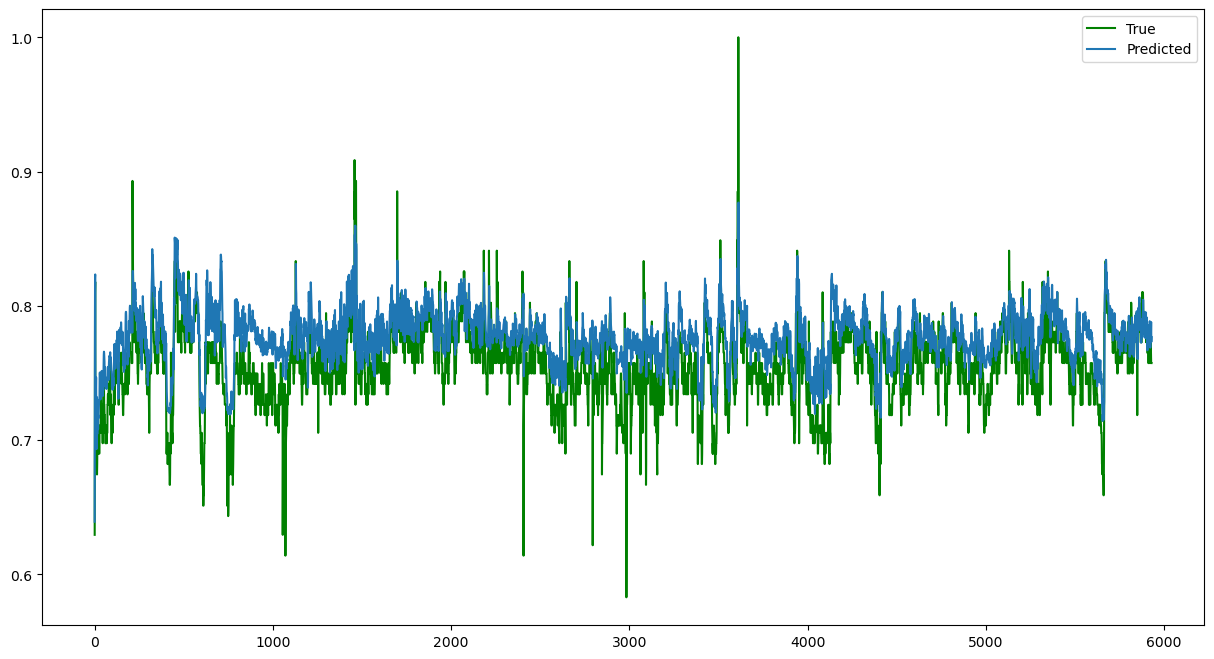

In [19]:
training_error=net.test(x_final,y_final,1)
print(training_error)
y_hat,h_t,c_t=net(x_final)
y_t=y_final.reshape(y_hat.shape).float()
y_hat=y_hat.reshape(y_hat.shape[0])
labels=y_t.reshape(y_t.shape[0])
outputs=[i.item() for i in y_hat]
labels=[i.item() for i in labels ]

fig=plt.figure(figsize=(15,8))
plt.plot(labels,color="green",label="True")
plt.plot(outputs,label="Predicted")
plt.legend()
plt.show()


## Test Error

0.0011367099359631538


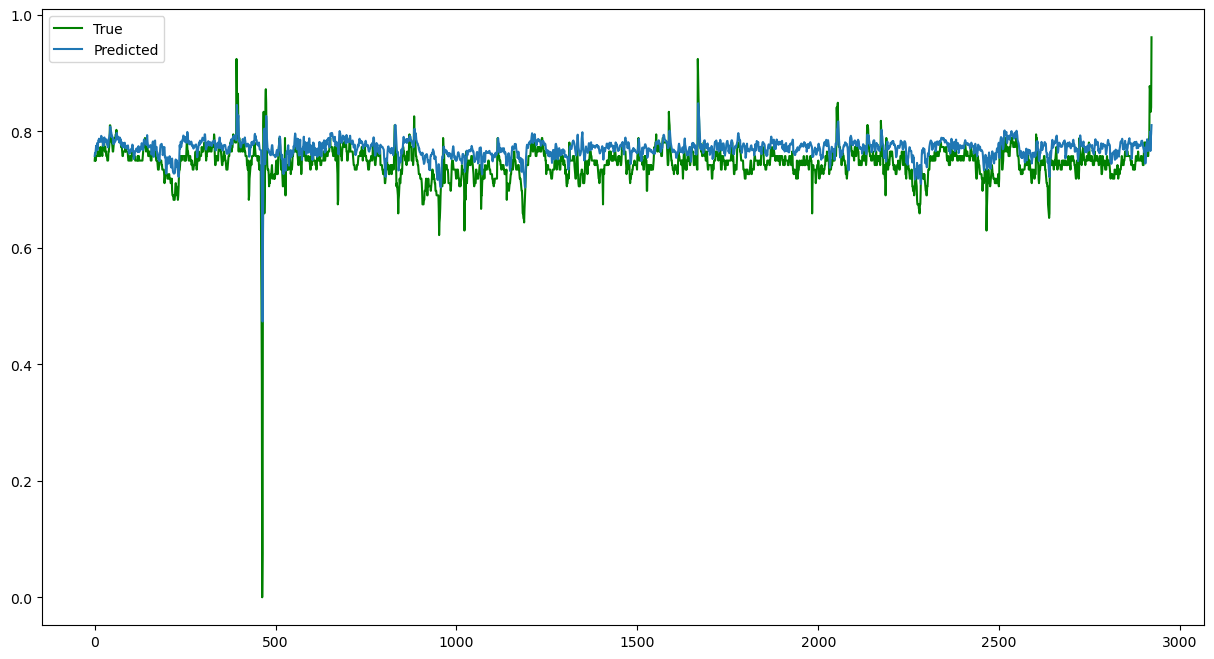

In [20]:
test_error=net.test(x_test,y_test,1)
print(test_error)
y_hat,h_t,c_t=net(x_test)
y_t=y_test.reshape(y_hat.shape).float()
y_hat=y_hat.reshape(y_hat.shape[0])
labels=y_t.reshape(y_t.shape[0])
outputs=[i.item() for i in y_hat]
labels=[i.item() for i in labels ]

fig=plt.figure(figsize=(15,8))
plt.plot(labels,color="green",label="True")
plt.plot(outputs,label="Predicted")
plt.legend()
plt.show()
